<a href="https://colab.research.google.com/github/shio0418/ML_exercise/blob/main/ml2024_04_regression_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 演習4: 回帰分析

適切な題材を選び、回帰モデルを学習せよ。ただし、以下の観点で採点を行うので、これらを満たすように解答せよ。

## 1. タスクの説明

選んだ回帰分析タスクの概要（入力と出力が何であるか等）を説明せよ。
<!-- 04:01 -->

今回私はカリフォルニアの住宅に関するデータセットを用いました。\
入力（８個）：ブロックの所得中央値・ブロックの家屋年齢の中央値・1世帯あたりの平均部屋・1世帯あたりの平均寝室数・ブロックの人・世帯人数の平均値・緯度・経度\
出力：住宅価格


入力の特徴量から住宅価格を予測します。

## 2. データの入手方法・構築方法

回帰分析を行う訓練データや評価データの入手方法を説明せよ。データを自作した場合は、作成方法を説明せよ。
<!-- 04:02 -->

以下のリンクを参考に、sklearnからデータセットをインポートしました。
そのうち７割を訓練用、３割をテスト用にしました
https://note.com/standenglish/n/n37bc5aa10166

In [ ]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

dataset = fetch_california_housing()
X, y = dataset.data, dataset.target
columns = dataset.feature_names

df = pd.DataFrame(X, columns=columns)
df['Target'] = y

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


## 3. モデルの学習

訓練データで回帰モデルを確率的勾配降下法により学習せよ。可能であれば、各エポック毎に以下の評価値を計算し、グラフとして表示せよ。これが難しければ、学習後の最終的な損失関数の値を報告せよ。

+ 訓練データ上の損失関数の値
+ 評価データ上の損失関数の値
<!-- 04:03 -->

In [ ]:
import numpy as np

max_epochs =  500000
eta0 = 0.001
eps = 1e-4
alpha = 0.0001

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
w = np.zeros(X_train.shape[1])
w
train_losses = []
eval_losses = []

for t in range(max_epochs):
    eta = eta0 / np.sqrt(1+t)
    i = np.random.randint(0, X_train.shape[0])
    y_hat = np.dot(X_train[i], w)
    grad = 2 * (y_hat - y_train[i]) * X_train[i] + 2 * alpha * w

    if np.sum(np.abs(grad)) < eps:
        print(f'epoch: {t}')
        break
    w -= eta * grad
    if t % 10000 == 0:
        train_losses.append(np.mean((y_train - np.dot( X_train, w)) ** 2))
        eval_losses.append(np.mean((y_test - np.dot( X_test, w)) ** 2))


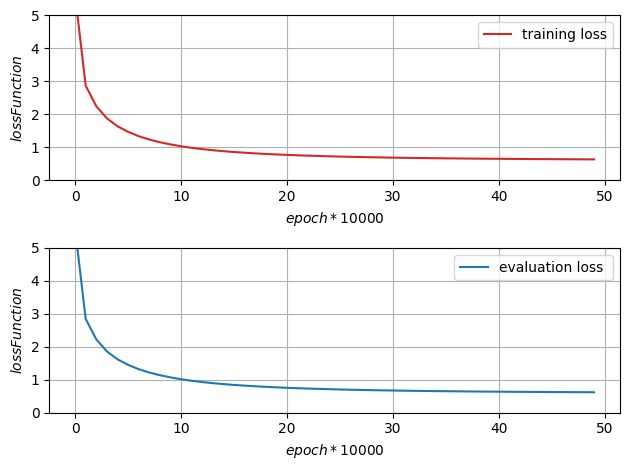

Final training loss : 0.6327962254907488
Final evaluation loss : 0.6214698476193108


In [ ]:
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(2, 1)
ax1.plot(train_losses,label='training loss',color='tab:red')
ax2.plot(eval_losses,label='evaluation loss ',color='tab:blue')
ax1.set_ylim(0, 5)
ax1.grid()
ax1.legend()
ax1.set_xlabel('$epoch * 10000$')
ax1.set_ylabel('$loss Function$')
ax2.set_ylim(0, 5)
ax2.grid()
ax2.legend()
ax2.set_xlabel('$epoch * 10000$')
ax2.set_ylabel('$loss Function$')
fig.tight_layout()
plt.show()

print(f'Final training loss : {train_losses[-1]}')
print(f'Final evaluation loss : {eval_losses[-1]}')


## 4. 回帰分析から得られた知見

回帰分析から得られた知見をまとめよ。また、回帰モデルがうまく学習できなかった場合は、その原因を分析・考察せよ。
<!-- 04:04 -->

最初、機械学習早見帳にあった4.6.2のコードを流用したときは、損失関数が５に収束してしまい、実行時間も遅かったため、以下を修正した



*   回帰について

1.   標準化\
ネットで調べたところ、確率的勾配降下法ではデータの標準化が有効なようなので行った。
2.   バイアス項の追加\
バイアス項を追加せず標準化すると損失関数が大きくなってしまいったため追加した。原因がわからなかったのでchatGPTを使った。

* 結果について
  * training lossesとevalating lossesがほぼ一致する結果となった。テストケースを分割する際のrandom_stateの値をいくつか試してみたが、ほぼ一致する結果となった。

  * 損失関数の値が0.6となり、まあまあ大きくなってしまったが、ミニバッチ学習をすればもう少し精度が良くなったかもしれない。
